In [99]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

df = pd.read_csv('student_mental_health_burnout.csv')
df = df.drop(columns=["student_id"])
#Conhecendo os dados

display(df.head())
print(f'O df tem {df.shape[1]} Colunas e {df.shape[0]} Linhas')
print('\n')
# retirando a coluna de id

#Percebe-se que algumas colunas como gender, stress_level, sleep_quality podem ser normalizadas por
#terem valores que são poucas classificações.

#Irei separar algumas colunas do tipo para analisá-las

colunas_analise = ['gender', 'course', 'year', 'stress_level', 'sleep_quality', 'internet_quality', 'burnout_level']

# como temos 3 colunas que são classificações / sem ordem, temos que ter um tratamento diferente com elas

colunas_ordinais = ['stress_level', 'sleep_quality', 'internet_quality',"year"]
colunas_str = ['gender', 'course']

for coluna in colunas_analise:

    print(f'Feature : {coluna}')
    print(f'Número de Valores possíveis: {df[coluna].unique()}')
    print('\n')

#Como previsto, algumas colunas podem ser padronizadas
#Como os valores são strings e não há valores fora do padrão, nãos será necessário corrigir as strings.

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


O df tem 19 Colunas e 150000 Linhas


Feature : gender
Número de Valores possíveis: ['Male' 'Female' 'Other']


Feature : course
Número de Valores possíveis: ['BTech' 'BCA' 'BSc' 'MBA' 'MCA' 'BBA']


Feature : year
Número de Valores possíveis: ['1st' '3rd' '4th' '2nd']


Feature : stress_level
Número de Valores possíveis: ['High' 'Low' 'Medium']


Feature : sleep_quality
Número de Valores possíveis: ['Average' 'Poor' 'Good']


Feature : internet_quality
Número de Valores possíveis: ['Good' 'Poor' 'Average']


Feature : burnout_level
Número de Valores possíveis: ['High' 'Low' 'Medium']




In [100]:
# Vou usar o ColumnTransformer com OneHotEncoder e OrdinalEncoder, para poder ter um mecanismo mais eficiente para
#tratar os dados
from sklearn.preprocessing import LabelEncoder

preprocessor = ColumnTransformer(transformers=[
    ('nao_ordinario', OneHotEncoder(drop='first'), colunas_str), #trata as colunas nao ordinais 
    ('ordinal', OrdinalEncoder(), colunas_ordinais) # trata as colunas ordinais
], remainder='passthrough')

novo_df = preprocessor.fit_transform(df) # Isso é uma matriz numpy!
novas_colunas = list(preprocessor.get_feature_names_out()) # pega o nome das colunas pós transformação
target = "remainder__burnout_level"
novas_features = novas_colunas.copy()
novas_features.remove(target)

print('Nome das novas colunas: ')
print(novas_colunas)
print('\n')

novo_df = pd.DataFrame(novo_df, columns=novas_colunas)

le = LabelEncoder()
novo_df[target] = le.fit_transform(novo_df[target])

#Visualizando os dados tratados:

display(novo_df.head(10))
print('\n')

# Agora, podemos dividir o dataset e formar os dados e o target

y_data = novo_df[target]
X_data = novo_df[novas_features]

print('Dados Gerais: ')
display(X_data)
print('\n')

Nome das novas colunas: 
['nao_ordinario__gender_Male', 'nao_ordinario__gender_Other', 'nao_ordinario__course_BCA', 'nao_ordinario__course_BSc', 'nao_ordinario__course_BTech', 'nao_ordinario__course_MBA', 'nao_ordinario__course_MCA', 'ordinal__stress_level', 'ordinal__sleep_quality', 'ordinal__internet_quality', 'ordinal__year', 'remainder__age', 'remainder__daily_study_hours', 'remainder__daily_sleep_hours', 'remainder__screen_time_hours', 'remainder__anxiety_score', 'remainder__depression_score', 'remainder__academic_pressure_score', 'remainder__financial_stress_score', 'remainder__social_support_score', 'remainder__physical_activity_hours', 'remainder__attendance_percentage', 'remainder__cgpa', 'remainder__burnout_level']




,nao_ordinario__gender_Male,nao_ordinario__gender_Other,nao_ordinario__course_BCA,nao_ordinario__course_BSc,nao_ordinario__course_BTech,nao_ordinario__course_MBA,nao_ordinario__course_MCA,ordinal__stress_level,ordinal__sleep_quality,ordinal__internet_quality,...,remainder__screen_time_hours,remainder__anxiety_score,remainder__depression_score,remainder__academic_pressure_score,remainder__financial_stress_score,remainder__social_support_score,remainder__physical_activity_hours,remainder__attendance_percentage,remainder__cgpa,remainder__burnout_level
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,6.1,10,3,4,2,6,1.8,66.5,9.63,0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0,...,3.0,2,10,8,5,9,1.9,55.8,6.04,1
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.5,2,7,8,6,3,0.8,85.0,8.31,0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,...,7.0,3,3,4,9,9,0.7,89.1,5.95,0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,5.4,7,7,6,4,4,1.7,58.7,8.51,1
5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,...,4.1,8,4,9,8,2,1.9,51.7,6.82,1
6,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,7.8,5,9,9,2,6,0.5,77.1,5.36,1
7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,0.0,...,7.6,5,10,3,10,6,0.6,59.3,5.91,1
8,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.3,1,1,7,2,1,1.7,70.6,7.23,1
9,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,...,11.5,4,2,4,3,7,1.3,65.0,6.26,2




Dados Gerais: 


,nao_ordinario__gender_Male,nao_ordinario__gender_Other,nao_ordinario__course_BCA,nao_ordinario__course_BSc,nao_ordinario__course_BTech,nao_ordinario__course_MBA,nao_ordinario__course_MCA,ordinal__stress_level,ordinal__sleep_quality,ordinal__internet_quality,...,remainder__daily_sleep_hours,remainder__screen_time_hours,remainder__anxiety_score,remainder__depression_score,remainder__academic_pressure_score,remainder__financial_stress_score,remainder__social_support_score,remainder__physical_activity_hours,remainder__attendance_percentage,remainder__cgpa
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,6.8,6.1,10,3,4,2,6,1.8,66.5,9.63
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0,...,4.7,3.0,2,10,8,5,9,1.9,55.8,6.04
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,4.8,1.5,2,7,8,6,3,0.8,85.0,8.31
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,...,6.7,7.0,3,3,4,9,9,0.7,89.1,5.95
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,6.7,5.4,7,7,6,4,4,1.7,58.7,8.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,1.0,...,8.2,11.3,9,9,5,3,10,2.0,54.2,7.82
149996,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,4.8,1.6,10,3,10,10,2,0.1,53.6,7.19
149997,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,4.4,4.6,10,8,6,4,7,1.6,90.7,9.78
149998,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,...,4.3,1.1,8,6,5,7,4,1.1,83.9,9.88


In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_data_normalizado = scaler.fit_transform(X_data[novas_features])
x_data = pd.DataFrame(x_data_normalizado, columns=novas_features)

print('Dados normalizados:')
display(x_data.head())


Dados normalizados:


,nao_ordinario__gender_Male,nao_ordinario__gender_Other,nao_ordinario__course_BCA,nao_ordinario__course_BSc,nao_ordinario__course_BTech,nao_ordinario__course_MBA,nao_ordinario__course_MCA,ordinal__stress_level,ordinal__sleep_quality,ordinal__internet_quality,...,remainder__daily_sleep_hours,remainder__screen_time_hours,remainder__anxiety_score,remainder__depression_score,remainder__academic_pressure_score,remainder__financial_stress_score,remainder__social_support_score,remainder__physical_activity_hours,remainder__attendance_percentage,remainder__cgpa
0,1.414978,-0.707616,-0.446924,-0.446075,2.244206,-0.449691,-0.446677,-1.220725,-1.224846,0.001216,...,0.208220,-0.126715,1.568648,-0.870460,-0.524228,-1.220387,0.168592,1.385272,-0.590551,1.519830
1,1.414978,-0.707616,-0.446924,-0.446075,2.244206,-0.449691,-0.446677,-1.220725,1.226398,1.225185,...,-1.246221,-1.101884,-1.216288,1.569404,0.866827,-0.173152,1.213712,1.558024,-1.333119,-0.552709
2,-0.706725,-0.707616,2.237518,-0.446075,-0.445592,-0.449691,-0.446677,0.001671,0.000776,0.001216,...,-1.176962,-1.573739,-1.216288,0.523748,0.866827,0.175926,-0.876528,-0.342248,0.693327,0.757782
3,1.414978,-0.707616,-0.446924,2.241773,-0.445592,-0.449691,-0.446677,-1.220725,1.226398,0.001216,...,0.138960,0.156398,-0.868171,-0.870460,-0.524228,1.223161,1.213712,-0.515000,0.977862,-0.604667
4,-0.706725,1.413196,-0.446924,2.241773,-0.445592,-0.449691,-0.446677,-1.220725,0.000776,0.001216,...,0.138960,-0.346914,0.524297,0.523748,0.171299,-0.522230,-0.528155,1.212520,-1.131862,0.873244


Acurácia Final: 0.338

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.34      0.46      0.39     12448
           1       0.34      0.34      0.34     12520
           2       0.33      0.21      0.26     12532

    accuracy                           0.34     37500
   macro avg       0.34      0.34      0.33     37500
weighted avg       0.34      0.34      0.33     37500



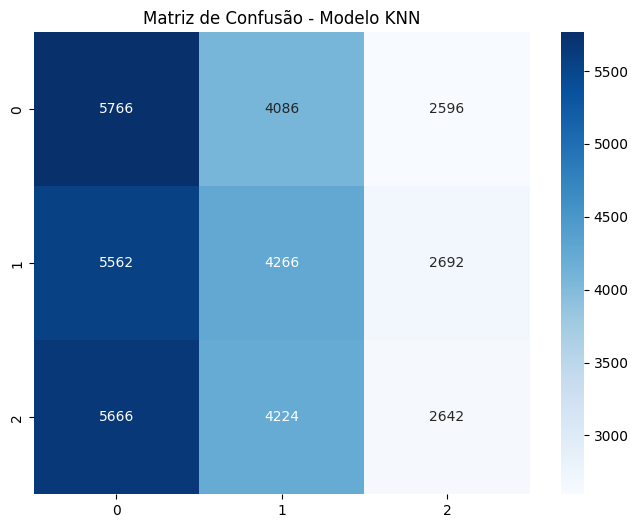

In [106]:
#importamos as ferramentas necessaárias para fazer o modelo preditivo e sua avaliação
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#dividimos os dados 75% treino e 25% teste
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.25)

#TREINAMENTO (KNN)
# Criando o modelo com 5 vizinhos
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

#AVALIAÇÃO
#Fazemos as previsões
y_pred = knn.predict(X_test)

#resultados
print(f"Acurácia Final: {accuracy_score(y_test, y_pred):.3f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

#Matriz de confusaão plotada
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='g')
plt.title('Matriz de Confusão - Modelo KNN')
plt.show()

In [108]:
from sklearn.model_selection import cross_val_score

# Testando a acurácia com 5 cortes diferentes
scores = cross_val_score(knn, X_data, y_data, cv=5, scoring='f1_macro')
print(f"F1-Score médio: {scores.mean():.2f}")

F1-Score médio: 0.33
